Consultando el main.py del repo, una probabilidad cerca de 1 sería bonafide y cerca de 0 spoof.

# 1. IMPORTS

In [ ]:
from __future__ import annotations
import re, ast, sys, csv
from pathlib import Path
from typing import Any, Dict
import numpy as np
import soundfile as sf
import torch
from scipy.signal import resample_poly
import torch.nn.functional as F
from data_utils import pad 
import librosa

# 2. RUTAS

In [5]:
REPO_DIR  = Path(r"C:\TFG\aasist") #ruta al repo AASIST
CONF_PATH = REPO_DIR / "config" / "AASIST.conf" #ruta al archivo de configuración
CKPT_PATH = REPO_DIR / "models" / "weights" / "AASIST.pth" #ruta al checkpoint del modelo  

INPUT_DIR = Path(r"C:\TFG\Datasets\Propio_Español") #ruta a los audios
OUT_CSV   = Path(r"C:\TFG\Código\aasist_results2.csv") #ruta al csv de salida

print("CONF existe:", CONF_PATH.exists(), CONF_PATH)
print("CKPT existe:", CKPT_PATH.exists(), CKPT_PATH)

CONF existe: True C:\TFG\aasist\config\AASIST.conf
CKPT existe: True C:\TFG\aasist\models\weights\AASIST.pth


# 3. LEER CONF
El archivo .conf contiene arquitectura del modelo, parámetros de entrenamiento, dataset y su protocolo, preprocesado y checkpoints

In [6]:
txt = CONF_PATH.read_text(encoding="utf-8", errors="ignore")

def extract_enclosing_dict(text: str, anchor: str) -> str:
    i = text.find(anchor)
    if i == -1:
        raise RuntimeError(f"No encuentro el anchor {anchor!r} en el conf.")
    j = i
    while j >= 0 and text[j] != "{":
        j -= 1
    if j < 0:
        raise RuntimeError("No encuentro '{' antes del anchor.")

    depth = 0
    in_str = False
    esc = False
    k = j
    while k < len(text):
        ch = text[k]
        if in_str:
            if esc:
                esc = False
            elif ch == "\\":
                esc = True
            elif ch == '"':
                in_str = False
        else:
            if ch == '"':
                in_str = True
            elif ch == "{":
                depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0:
                    return text[j:k+1]
        k += 1
    raise RuntimeError("No pude cerrar el bloque '{...}'.")

# 4. CONSTUIR d_args
d_args(arquitectura) contiene:
- first_conv: parámetros del primer bloque convolucional del modelo
- filts: estructura que marca cuántos canales/filtros usa el modelo en cada etapa/bloque
- get_dims: dimensiones internas del bloque del grafo de atención
- pool_ratios: lista de ratios usados para pooling
- temperatures: controla lo suave o agresiva que es una selección

In [7]:
block = extract_enclosing_dict(txt, '"first_conv"')
block = re.sub(r",\s*(\}|\])", r"\1", block)  # quita comas colgantes
d_args: Dict[str, Any] = ast.literal_eval(block)

required = ["filts", "gat_dims", "pool_ratios", "temperatures", "first_conv"]
missing = [k for k in required if k not in d_args]
print("d_args OK. Missing:", missing)
if missing:
    raise RuntimeError("No se extrajo el dict correcto del conf.")

d_args OK. Missing: []


# 5. INSTANCIAR EL MODELO

In [8]:
if str(REPO_DIR) not in sys.path: 
    sys.path.insert(0, str(REPO_DIR)) #añade la raiz del repo al path

from models.AASIST import Model

device = "cpu"
model = Model(d_args).to(device).eval()
print("Modelo instanciado")

Modelo instanciado


# 6. CARGAR CHEKPOINT
El checkpoint sirve para cargar los pesos del entrenamiento

In [9]:
state = torch.load(str(CKPT_PATH), map_location=device)
if isinstance(state, dict):
    for key in ("state_dict", "model", "model_state_dict", "net"):
        if key in state and isinstance(state[key], dict):
            state = state[key]
            break

if isinstance(state, dict) and any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}

missing_keys, unexpected_keys = model.load_state_dict(state, strict=False)
print(f"Checkpoint cargado (missing={len(missing_keys)}, unexpected={len(unexpected_keys)})")

Checkpoint cargado (missing=0, unexpected=0)


# 7. HELPERS DE AUDIO + VENTANA DESLIZANTE
Los helpers sirven para dejar los audios en un modelo estándar: mono(un canal), 16 Khz.
La ventana sirve para audios más largos de 4 segundos, los parte en ventanas de 4 segundos con solapamiento de dos para que no se quede información en el borde de una ventana.

In [ ]:
def load_mono_16k(path, target_sr=16000):
    x, sr = sf.read(str(path), always_2d=False)
    x = x.astype(np.float32)
    if x.ndim > 1:
        x = np.mean(x, axis=1).astype(np.float32)
    if sr != target_sr:
        x = librosa.resample(x, orig_sr=sr, target_sr=target_sr).astype(np.float32)
    x = np.clip(x, -1.0, 1.0).astype(np.float32)

    return x


def make_windows(x: np.ndarray, sr=16000, win_sec=4.0, hop_sec=2.0):
    win = int(win_sec * sr)
    hop = int(hop_sec * sr)
    if len(x) <= win:
        y = np.zeros(win, dtype=np.float32)
        y[:len(x)] = x
        return [y]
    out=[]
    for s in range(0, len(x)-win+1, hop):
        out.append(x[s:s+win])
    if (len(x)-win) % hop != 0:
        out.append(x[-win:])
    return out

# 8. INFERENCIA

In [11]:
#Este hace media de probabilidades de todas las ventanas
@torch.no_grad()
def prob1_mean_for_file(wav: Path, win_sec=4.0, hop_sec=2.0):
    x = load_mono_16k(wav, 16000)
    ws = make_windows(x, 16000, win_sec, hop_sec)
    ps=[]
    for w in ws:
        t = torch.from_numpy(w).unsqueeze(0).to(device)  # (1,T)

        out = model(t)
        if isinstance(out, (tuple, list)):
            logits = next(o for o in out if torch.is_tensor(o) and o.ndim == 2 and o.shape[1] == 2)
        else:
            logits = out


        p1 = torch.softmax(logits, dim=1)[0,1].item()
        ps.append(p1)

    return float(np.mean(ps)), len(x)/16000.0, len(ws) #devuelve la probabilidad media contando todas las ventanas

In [ ]:
#Este sería sin ventanas

CUT = 64600  # ~4.04s 

@torch.no_grad()
def score_without_windows(wav: Path):
    x = load_mono_16k(wav, 16000)              
    x4 = pad(x, CUT).astype(np.float32)      

    t = torch.from_numpy(x4).unsqueeze(0).to(device)  

    out = model(t)
    if isinstance(out, (tuple, list)):
        logits = next(o for o in out if torch.is_tensor(o) and o.ndim == 2 and o.shape[1] == 2)
    else:
        logits = out

    score_bonafide = logits[0, 1].item()

    prob_bonafide = F.softmax(logits, dim=1)[0, 1].item()

    duration_sec = len(x) / 16000.0
    return score_bonafide, prob_bonafide, duration_sec


In [ ]:
#Este sumando los logists de todas las ventanas antes de hacer la media

CUT = 64600

@torch.no_grad()
def multiwindow_prob_bonafide(wav: Path, win_sec=4.0, hop_sec=2.0):
    x = load_mono_16k(wav, 16000)
    ws = make_windows(x, 16000, win_sec, hop_sec)

    logits_sum = None

    for w in ws:
        w = pad(w, CUT).astype(np.float32)
        t = torch.from_numpy(w).unsqueeze(0).to(device)

        _, logits = model(t) 

        logits_sum = logits if logits_sum is None else logits_sum + logits

    prob_bona = F.softmax(logits_sum, dim=1)[0, 1].item()
    score_bona = logits_sum[0, 1].item() 

    return prob_bona, score_bona, len(x)/16000.0, len(ws)


# 9. TRATAR LOS AUDIOS

In [14]:
files = sorted(INPUT_DIR.rglob("*.wav"))
print("Audios encontrados:", len(files))
if not files:
    raise RuntimeError("No hay .wav en INPUT_DIR (ni en subcarpetas).")

with OUT_CSV.open("w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["filename", "prob1_mean", "duration_sec", "n_windows"])
    for i, fp in enumerate(files, 1):
        #p1, dur, nw = prob1_mean_for_file(fp, win_sec=4.0, hop_sec=2.0)
        #prob_bona, score_bona, dur, nw = multiwindow_prob_bonafide(fp, win_sec=4.0, hop_sec=2.0)
        #w.writerow([str(fp), prob_bona, dur, nw])
        score_bona, prob_bona, dur = score_without_windows(fp)
        w.writerow([str(fp), prob_bona, dur])

print("Resultados en:", OUT_CSV)

Audios encontrados: 100
Resultados en: C:\TFG\Código\aasist_results2.csv


Como shap no se puede aplicar sobre aasist porque recibe un audio crudo en vez de caracteristicas y es un modelo muy costoso de llamar muchas veces(explicación vaga), he intentado usar un modelo surrogate que imite la salida de aasist

# 1. IMPORTS

Hay alguno repetido con los imports del uso del modelo para poder ejecutar ambas cosas de forma independiente.

In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor
import shap

c:\TFG\aasist\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2.RUTAS

In [ ]:
FEATURES_CSV = "features.csv" 
AASIST_CSV   = "aasist_results2.csv"    
OUT_CSV      = "features_with_aasist.csv"

AASIST_SCORE_COL = "prob1_mean"  #nombre de la columna del aasist.csv

FILENAME_NORMALIZATION = "basename" #para el punto 4

# 3. Carga de csvs

In [12]:
feats = pd.read_csv(FEATURES_CSV)
aas  = pd.read_csv(AASIST_CSV)

# 4. Comparación de rutas y validación de la columna score

Normaliza las rutas de ambos csvs para que no haya errores por rutas distintas aunque se refieran al mismo audio y además luego facilita el nombrar archivos para la separación manual de los audios en train y test.

In [ ]:
def normalize_fn(x: str) -> str:
    x = str(x)
    if FILENAME_NORMALIZATION == "basename": #solo el nombre del archivo
        return os.path.basename(x)
    if FILENAME_NORMALIZATION == "normpath": #toda la ruta
        return os.path.normpath(x)
    return x 

feats["filename"] = feats["filename"].apply(normalize_fn)
aas["filename"]  = aas["filename"].apply(normalize_fn)

#asegura que la columna de score existe
if AASIST_SCORE_COL not in aas.columns:
    raise ValueError(
        f"No encuentro la columna '{AASIST_SCORE_COL}' en {AASIST_CSV}. "
    )

# 5. Merge

El resultado es el csv de caracteristicas más la fila de score de aasist. Además, inner descarta archivos que no esten en ambos por si acaso.

In [14]:
df = feats.merge(aas[["filename", AASIST_SCORE_COL]], on="filename", how="inner")

#alguna comprobación para el merge
print("Filas features:", len(feats))
print("Filas aasist:", len(aas))
print("Filas merge:", len(df))

#el logit sirve para que los valores no estén cerrado entre [0,1] y crezca de manera más lineal
p = df[AASIST_SCORE_COL].clip(1e-6, 1-1e-6)
df["aasist_logit_bona"] = np.log(p/(1-p))
AASIST_SCORE_COL = "aasist_logit_bona"

#reordena para poner prob de bonafide al principio del csv
cols = df.columns.tolist()
new_order = ["filename", AASIST_SCORE_COL] + [c for c in cols if c not in ("filename", AASIST_SCORE_COL)]
df = df[new_order]

df.to_csv(OUT_CSV, index=False)
print(f"Guardado: {OUT_CSV}")

Filas features: 100
Filas aasist: 100
Filas merge: 100
Guardado: features_with_aasist.csv


# 6. Construir X e y(columna a imitar) y arreglo de formatos para evitar errores 

In [ ]:
#sirve para quitar las columnas que no son features y no se quieren usar para entrenar el surrogate
DROP_COLS = ["filename", AASIST_SCORE_COL, "prob1_mean",] 

X = df.drop(columns=[c for c in DROP_COLS if c in df.columns]).copy()
y = df[AASIST_SCORE_COL].astype(float).values

#todo lo que no sea numérico lo convierte a NaN
X = X.apply(pd.to_numeric, errors="coerce")

# 7. División del dataset

Para train usamos los audios que también se usaron en un preentreno de aasist

In [16]:
test_filenames = {"E_10_G.wav", "E_10_N.wav", "E_19_G.wav","E_19_N.wav","E_20_G.wav","E_20_N.wav","E_29_G.wav","E_29_N.wav","E_30_G.wav","E_30_N.wav","E_39_G.wav","E_39_N.wav","E_40_G.wav","E_40_N.wav","E_49_G.wav","E_49_N.wav","E_50_G.wav","E_50_N.wav","E_9_G.wav","E_9_N.wav"} 

df["is_test"] = df["filename"].isin(test_filenames)

X_train = X[~df["is_test"]].copy()
y_train = y[~df["is_test"]]

X_test  = X[df["is_test"]].copy()
y_test  = y[df["is_test"]]

# 8. Entrenar el surrogate y fidelidad con aasist

R2 sirve para ver como de fiel es el surrogate, como vemos al entrenar si que tiene un valor cercano a 1 lo cual es aceptable pero en test tiene un valor que no refleja el modelo de aasist

In [17]:
sur = XGBRegressor(
    n_estimators=100, #número de árboles, subirlo puede llevar a sobreajuste
    max_depth=3, #prof máxima de cada árbol
    learning_rate=0.05, #le peso de cada árbol nuevo
    subsample=0.7, #% de audios que usa cada árbol
    colsample_bytree=0.7, #% de features que usa cada árbol
    reg_lambda=10.0, #penaliza pesos grandes
    reg_alpha=1.0, #penaliza pesos pequeños
    min_child_weight=5, #controla la creación de nodos nuevos
    gamma=0.5, #coste mínimo para hacer un split
    random_state=0 #aleatoriedad 
)
sur.fit(X_train, y_train)

train_pred = sur.predict(X_train)
test_pred  = sur.predict(X_test)
print("R2 train:", r2_score(y_train, train_pred))
print("R2 test :", r2_score(y_test, test_pred))

R2 train: 0.7512567390989654
R2 test : 0.039327820772911304


# 9. Aplicar shap

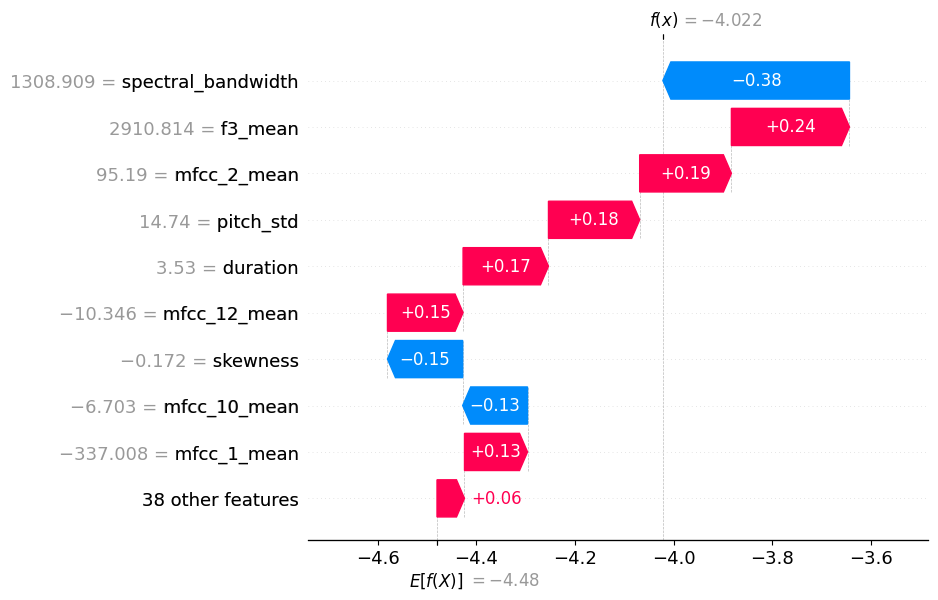

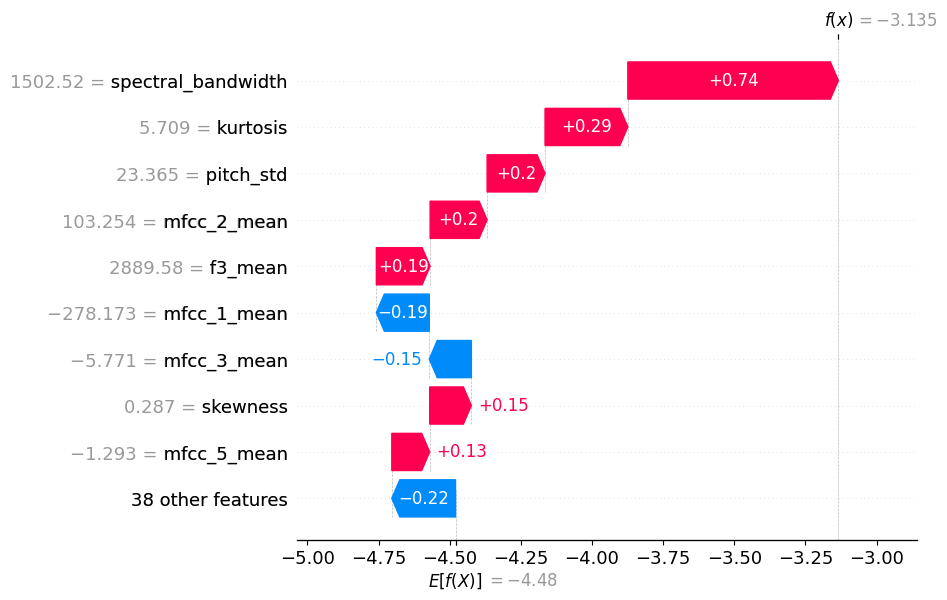

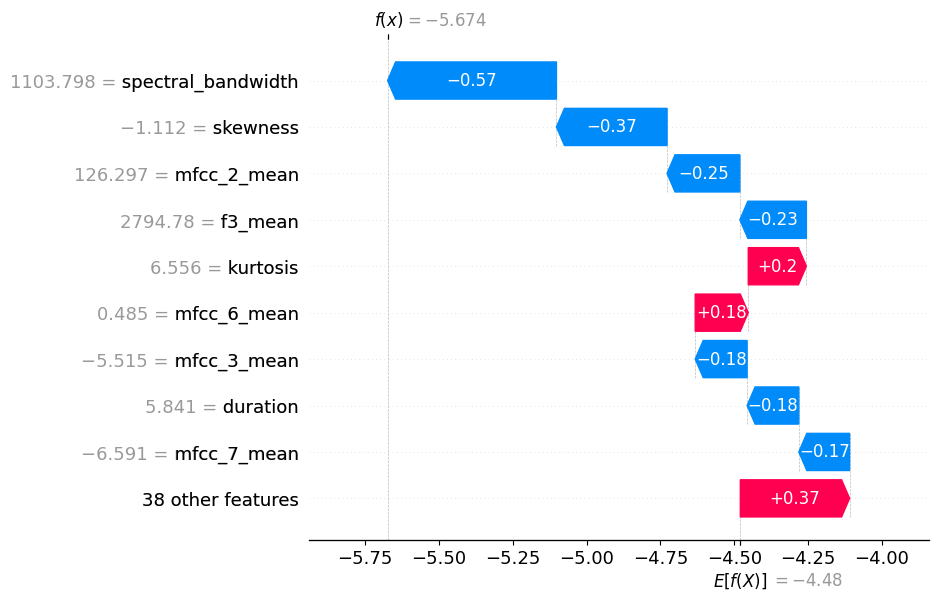

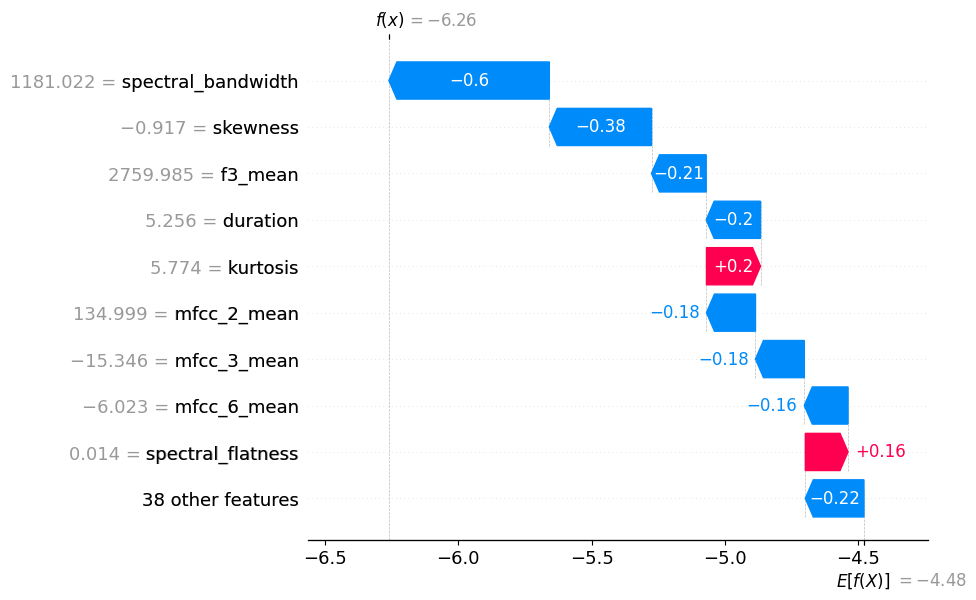

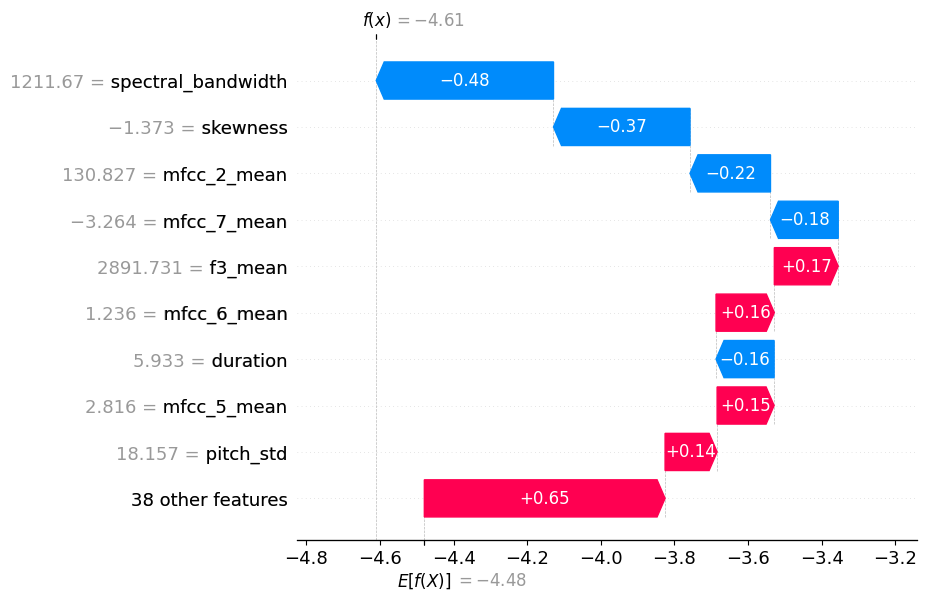

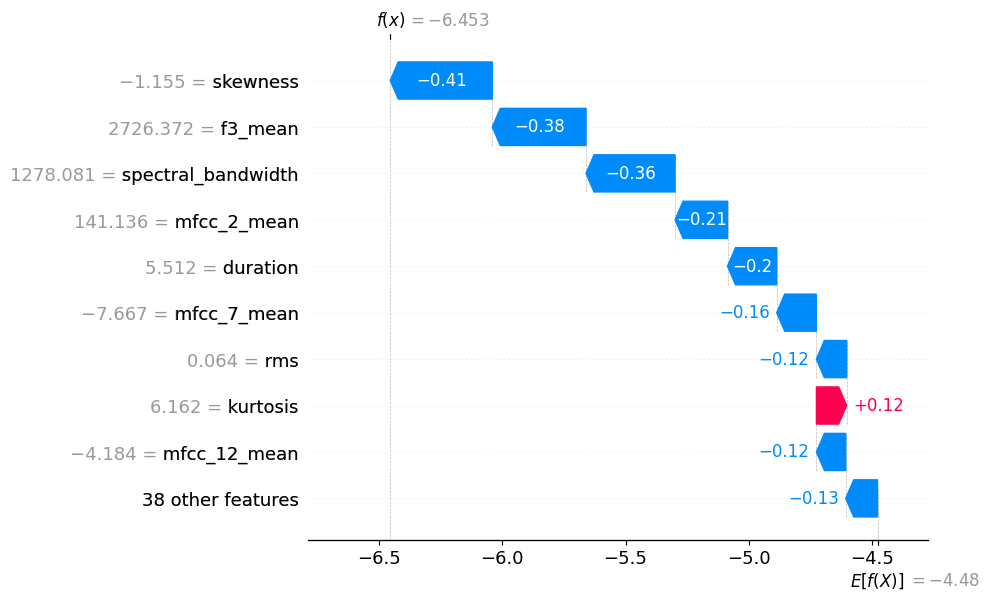

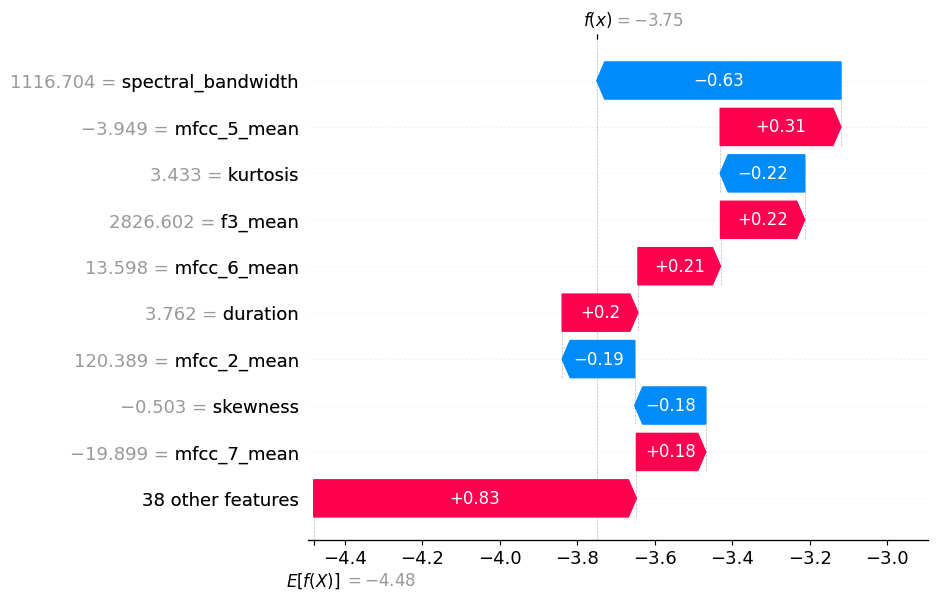

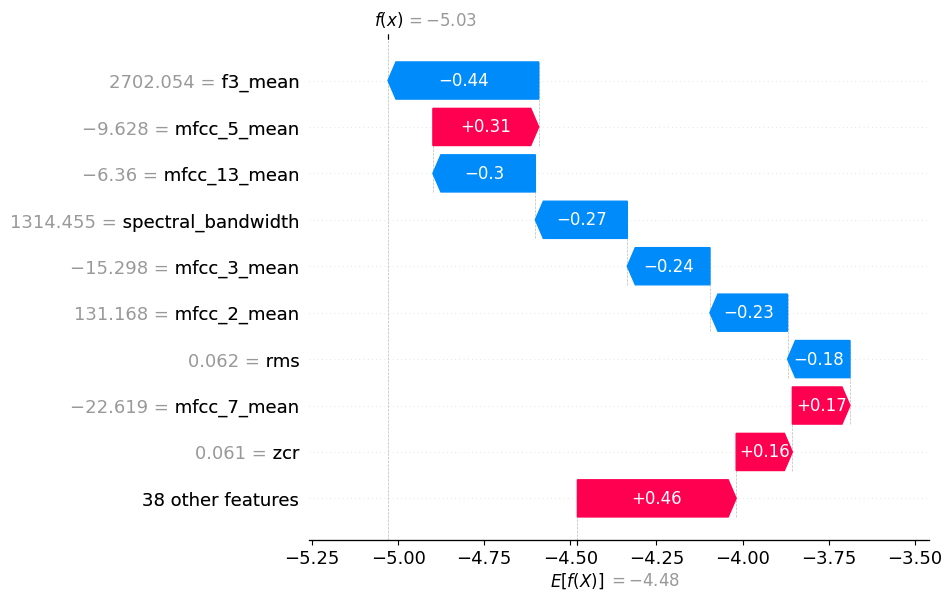

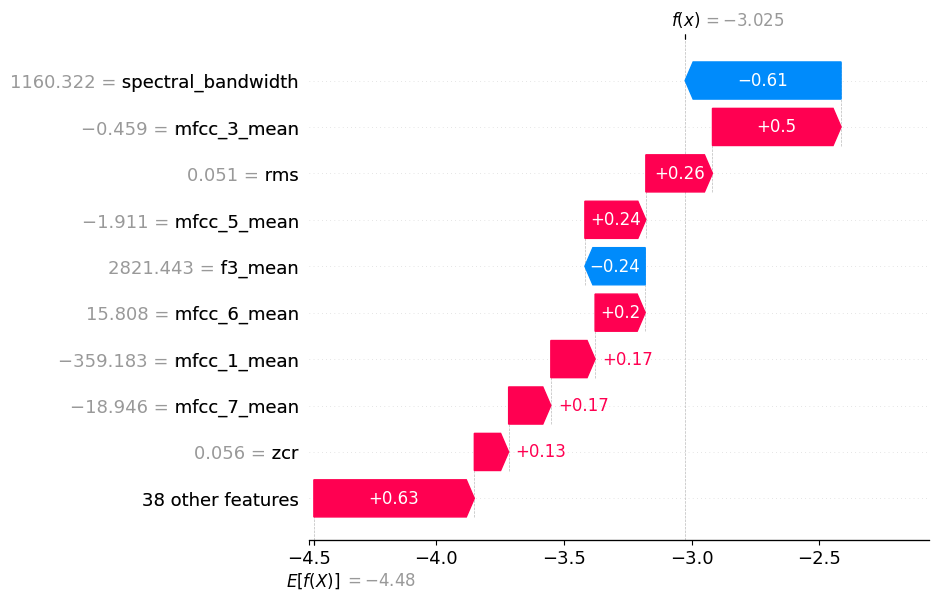

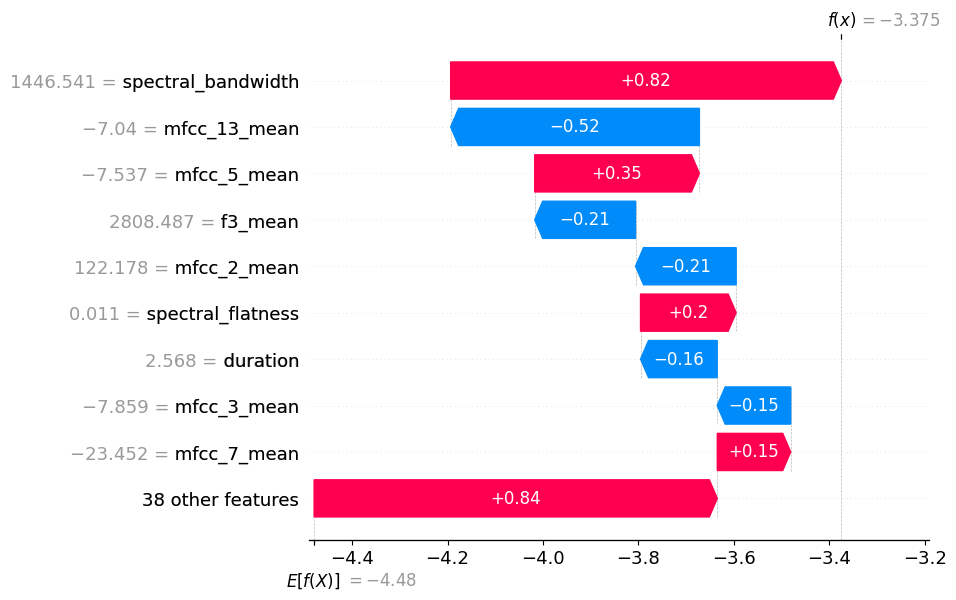

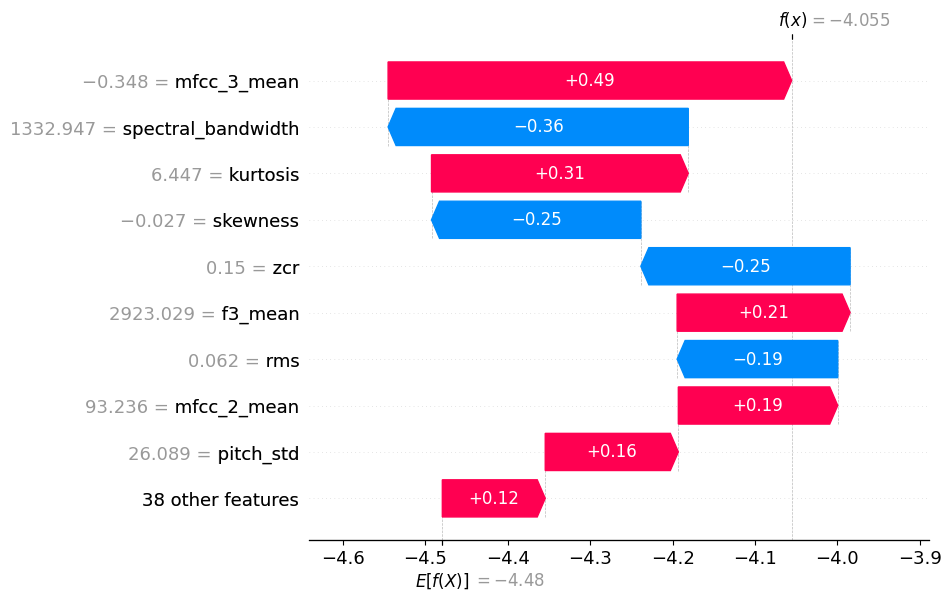

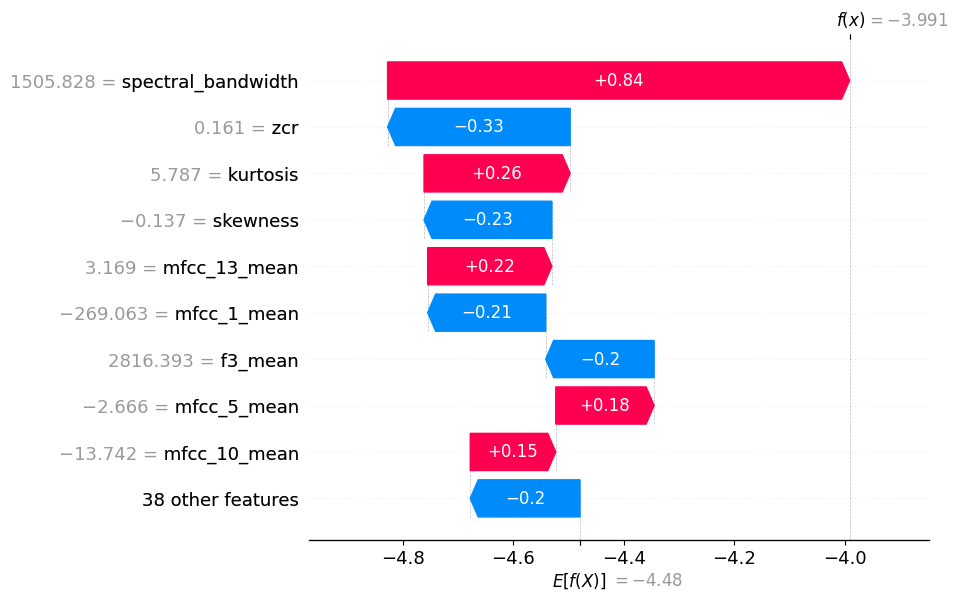

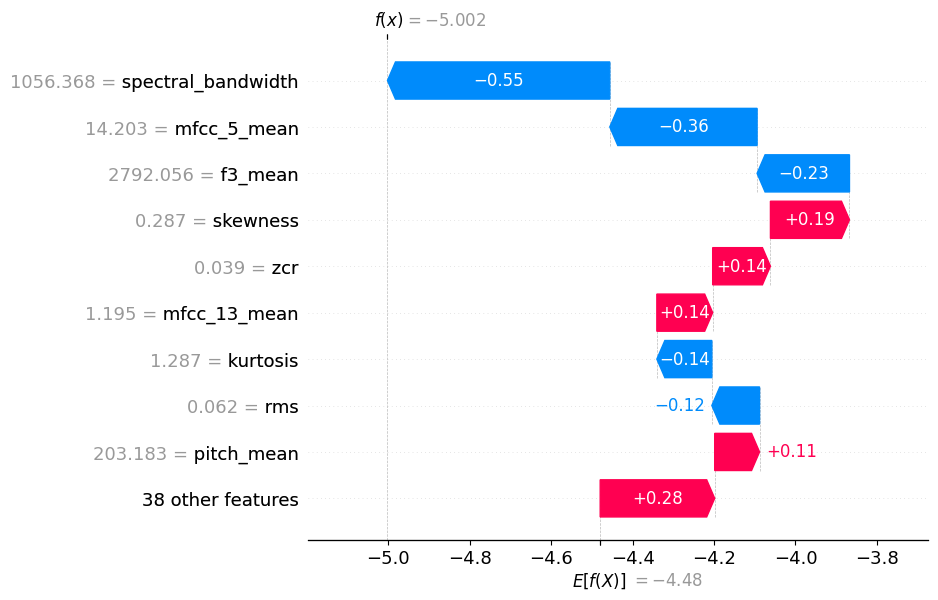

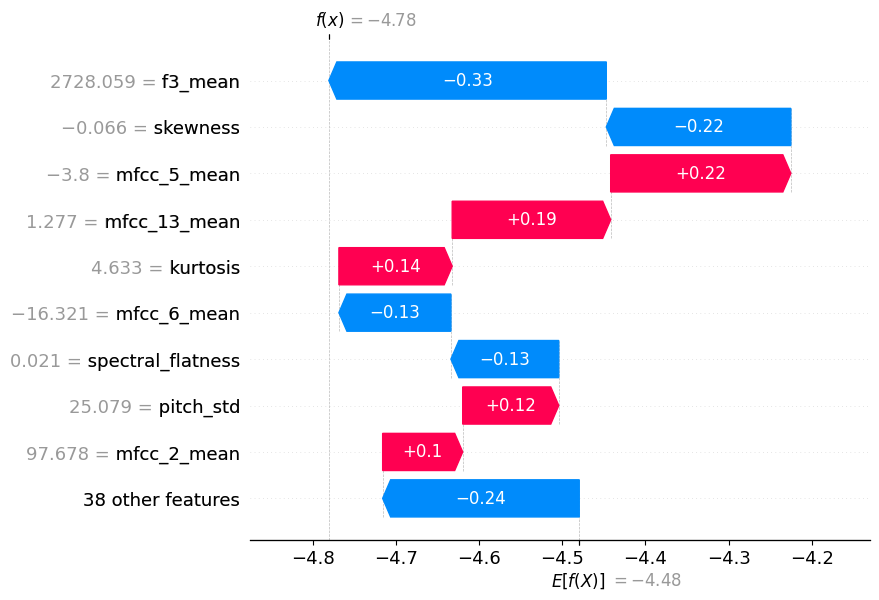

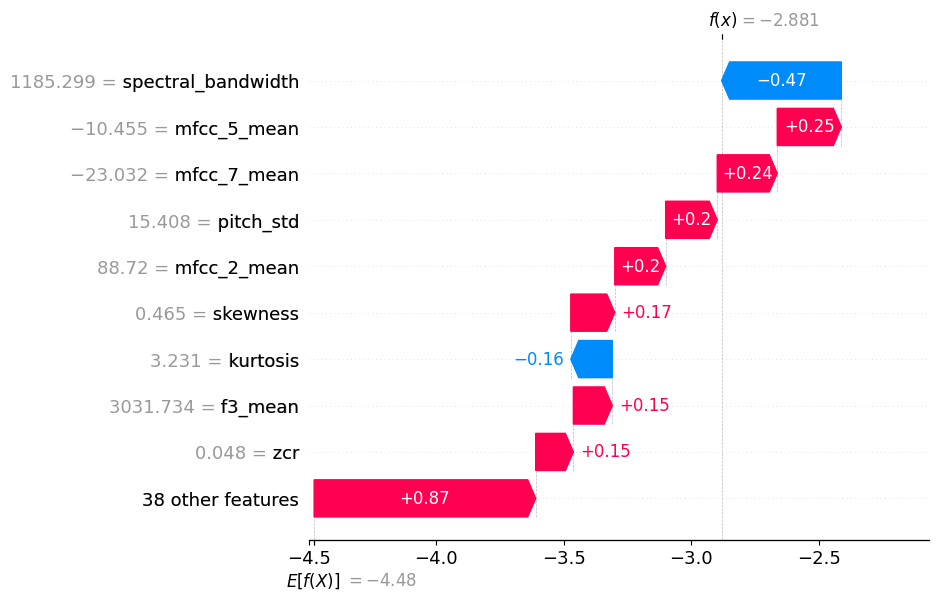

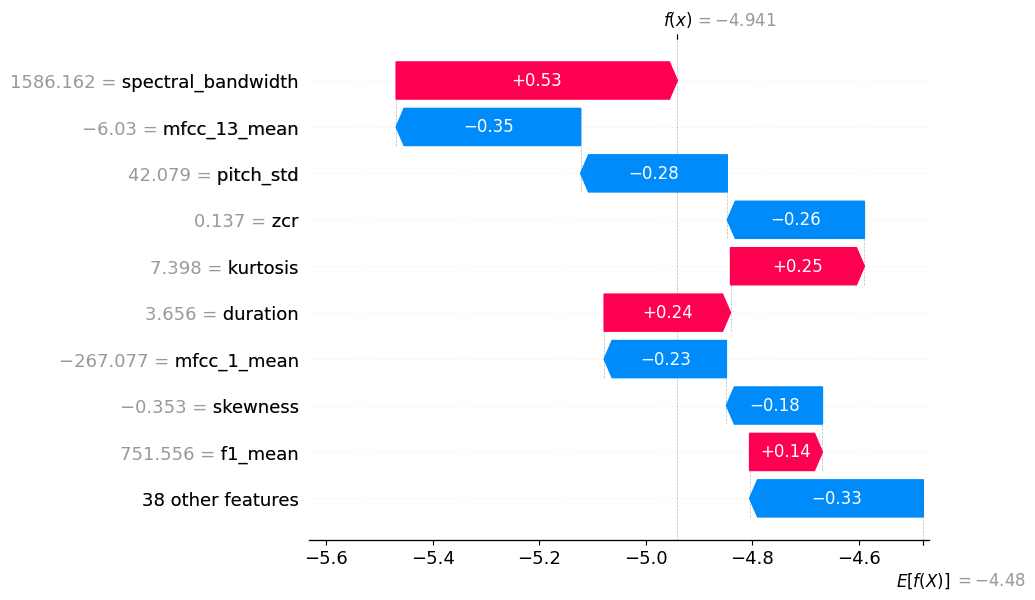

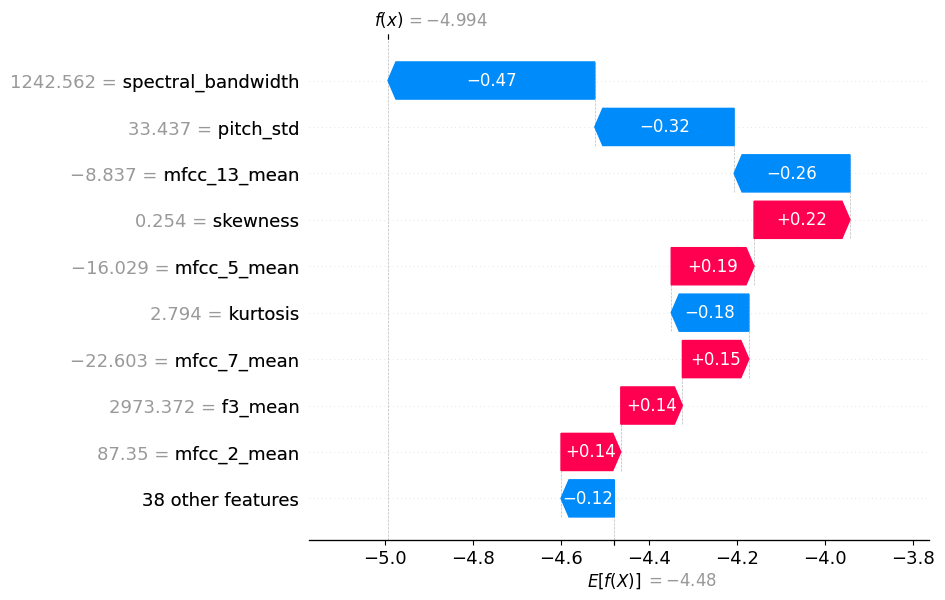

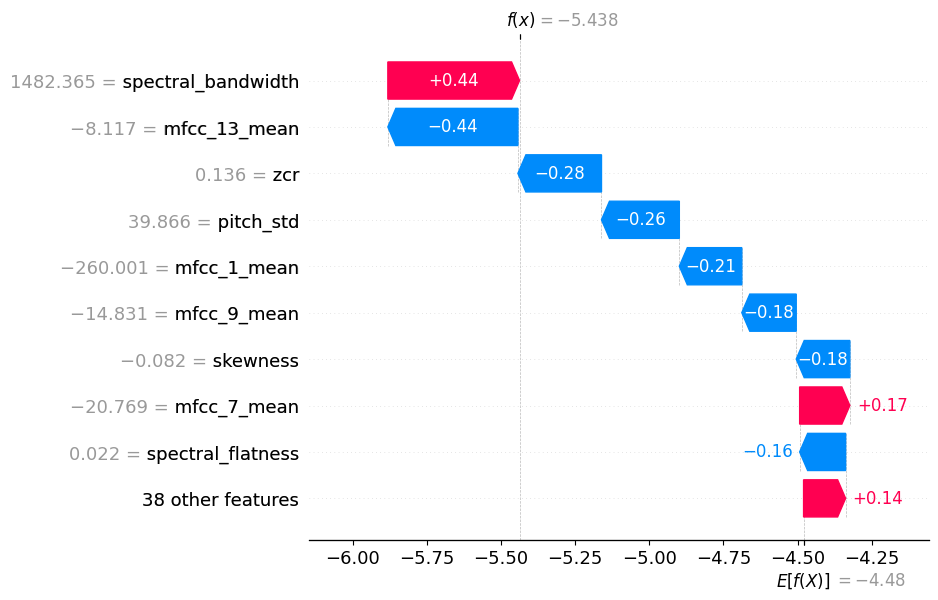

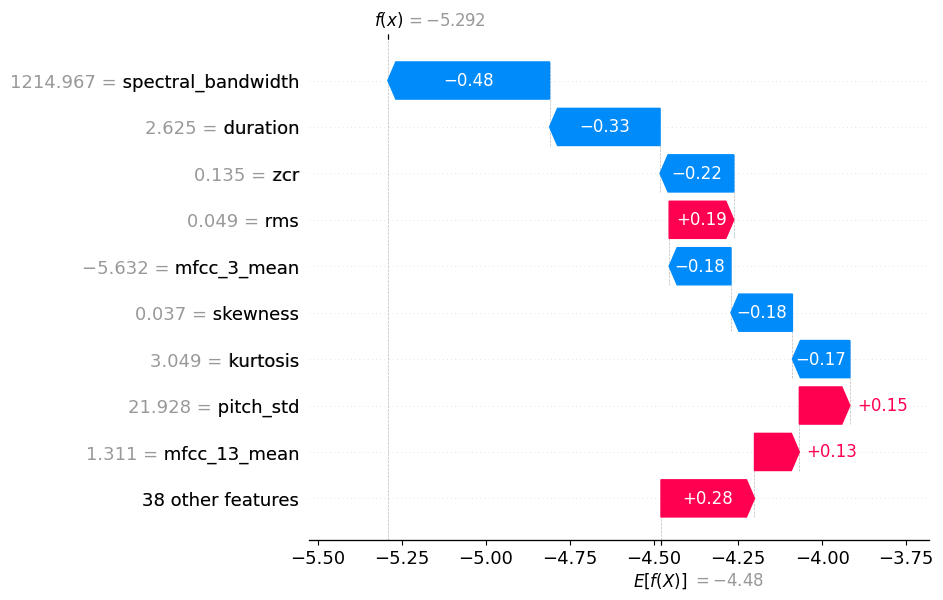

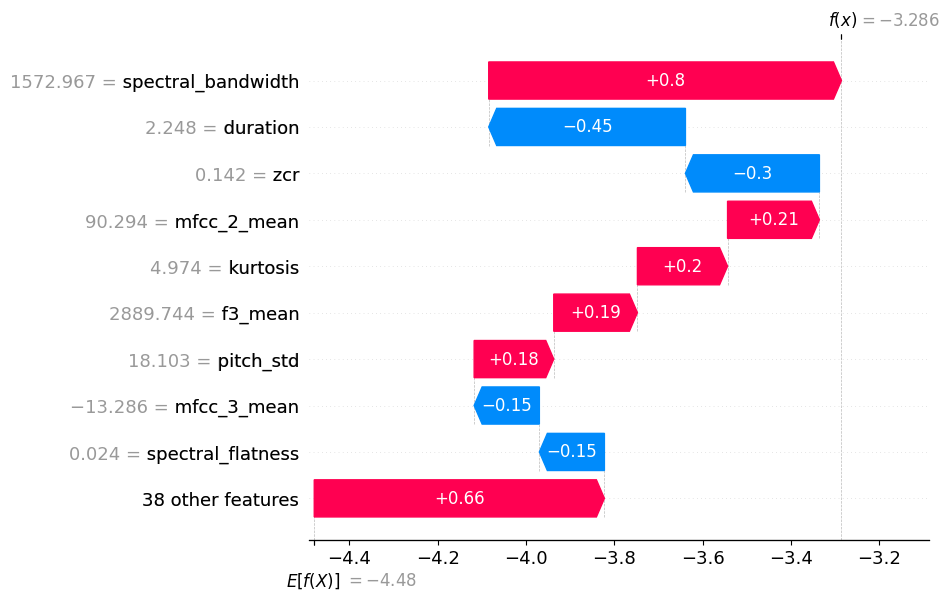

In [81]:
explainer = shap.Explainer(sur, X_train)
shap_values = explainer(X_test)

for i in range(20):
    shap.plots.waterfall(shap_values[i])